# Datenvisualisierung
Dieses Jupyter-Notebook ist für die graphische Darstellung der Daten.

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
from metrics import print_metrics
import warnings
warnings.filterwarnings('ignore')

Mit ```project_id``` können die Daten die zum Trainieren des Modells verwendet werden aus der Datenbank abgerufen werden.

Mit ```priject_id_validation``` können die Daten die zum Validieren des Modells verwendet werden aus der Datenbank abgerufen werden.

Mit ```essids``` werden die ESSIDs ausgewählt die beachtet werden sollen.

```blue``` und ```red``` sind Farben die in den Plots verwendet werden.

In [5]:
project_id = 3
priject_id_validation = 4
essids = ['eduroam']

blue = "#0072B2"
red = "#E69F00"

# Mothode zum Daten laden
Mit der Methode ```load_data``` können die Daten aus der Datenbank abgerufen werden. Die Daten werden gefiltert und pro Messung wird ein Datensatz erstellt.

In [6]:
def load_data(id, essids):
    engine = create_engine('sqlite:///sensordaten.db')
    query = "SELECT sensor_id, timestamp, position_x, position_y, bssid, rssi, project_id, essid FROM wifi_signal_data WHERE project_id={} and essid in ({})".format(
        id, ', '.join(f"'{essid}'" for essid in essids))
    df = pd.read_sql(query, engine)
    pivot_df = df.pivot_table(
        index=['sensor_id', 'timestamp', 'position_x', 'position_y'],
        columns='bssid',
        values='rssi'
    )
    pivot_df = pivot_df.reset_index()

    X = pivot_df.drop(['sensor_id', 'timestamp', 'position_x', 'position_y'], axis=1)
    y = pivot_df[['position_x', 'position_y']].copy()

    return X, y


# Daten abrufen
Jetzt werden die Daten für das Training aus dem Trainings-Projekt und zum validieren aus dem Validierungs-Projekt getrennt voneinander geladen. Die Daten aus dem Trainingsprojekt werden in Test und Trainingsdaten aufgeteilt.

In [7]:
X, y = load_data(project_id, essids)
X_validation, y_validation = load_data(priject_id_validation, essids)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Diagramme

## Anordnung der Messdaten


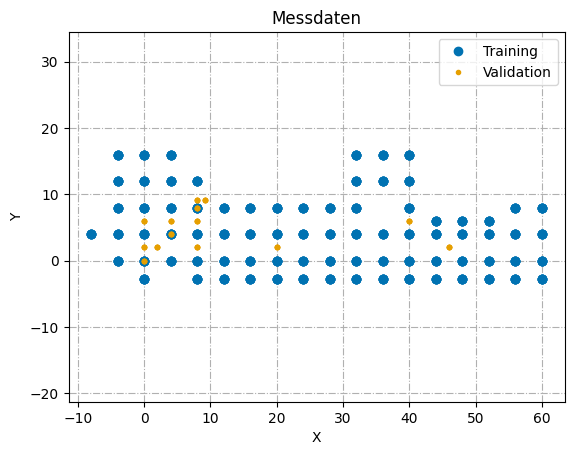

In [8]:
fig, ax = plt.subplots()

ax.grid(True, linestyle='-.')
ax.axis('equal')

ax.plot(y.loc[:, 'position_x'],y.loc[:, 'position_y'], 'o', color=blue, label='Training')
ax.plot(y_validation.loc[:, 'position_x'],y_validation.loc[:, 'position_y'], '.', color=red, label='Validation')


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Messdaten")
ax.legend()

plt.show()

## Modell trainieren
Hier trainieren wir das Modell wie in ```02_train_project.ipynb``` beschrieben.

In [9]:
# Modelle definieren
estimators = [
    ("rf", make_pipeline(MinMaxScaler(feature_range=(-70, -20)),
                         RandomForestRegressor(random_state=0, n_estimators=100, min_samples_split=2))),
    ("gb", make_pipeline(SimpleImputer(missing_values=np.nan, strategy="constant", fill_value=-95), StandardScaler(),
                         HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=31, learning_rate=0.2))),
    ("svr", make_pipeline(SimpleImputer(missing_values=np.nan, strategy="constant", fill_value=-95),
                          MinMaxScaler(feature_range=(-70, -20)), SVR(kernel='poly', C=10, epsilon=0.9, degree=10))),
]

pipeline = MultiOutputRegressor(StackingRegressor(estimators=estimators, final_estimator=KNeighborsRegressor(n_jobs=-1, n_neighbors=3)))

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print_metrics(y_pred, y_test)

RMSE: 1.7663009845288329
RMSE X: 1.5075991289512698 RMSE Y: 1.1223844419106306
MAE X: 0.9957805907172999 MAE Y: 0.5738396624472574
Mean Position Error: 1.3325402228102854
Median Position Error: 1.3333333333333335


## Validierungsdaten
### Validierungsdaten erzeugen
Es wird ein neues Dataframe erstellt mit genau den gleichen Spalten wie der Trainingsdatensatz. Wichtig ist die Reihenfolge der Spalten. Diese muss exakt gleich sein wie beim Traing des Modells.

In [10]:
df_test = pd.DataFrame(columns=X_train.columns)

for i, row in X_validation.iterrows():
    for col in X_train.columns:
        if col in X_validation.columns:
            df_test.loc[i, col] = row[col]

### Vorhersage der Validierungsdaten
Die Validierungsdaten aus dem extra Projekt werden nun in das Modell gegeben.

In [11]:
y_validation_pred = pipeline.predict(df_test)

### Mitteln der Predictions
Da an jedem Standpunkt mehrere Messungen durchgeführt wurden, werden die Vorhersagen gemittelt.

In [12]:
dft = pd.concat([pd.DataFrame(y_validation_pred, columns=["pred_x", "pred_y"]), y_validation.copy()], axis=1)

mittelwerte = (
    dft.groupby(["position_x", "position_y"])[["pred_x", "pred_y"]]
    .mean()
    .reset_index()
)

dy_test = mittelwerte.drop(['position_x', 'position_y'], axis=1).rename(columns={'pred_x': 'position_x'}).rename(columns={'pred_y': 'position_y'})
dy_pred = mittelwerte.drop(['pred_x', 'pred_y'], axis=1)

### Darstellen der Validierungsdaten

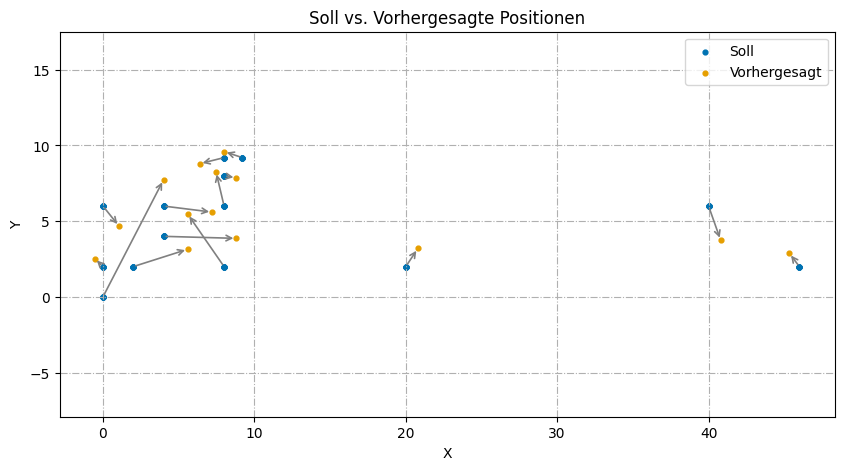

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.grid(True, linestyle='-.')
ax.axis('equal')
for _, row in mittelwerte.iterrows():
    plt.annotate(
        "",  # kein Text, nur Pfeil
        xy=(row["pred_x"], row["pred_y"]),   # Pfeilspitze
        xytext=(row["position_x"], row["position_y"]),               # Startpunkt
        arrowprops=dict(
            arrowstyle="->",
            color="gray",
            lw=1.2
        )
    )
ax.scatter(y_validation['position_x'],y_validation['position_y'], s=12, color=blue, label="Soll")
ax.scatter(mittelwerte["pred_x"],mittelwerte["pred_y"], s=12, color=red, label="Vorhergesagt")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Soll vs. Vorhergesagte Positionen")
ax.legend()
plt.show()
fig.savefig("test.png", dpi=300)

### Darstellen einer einzelnen Vorhersage

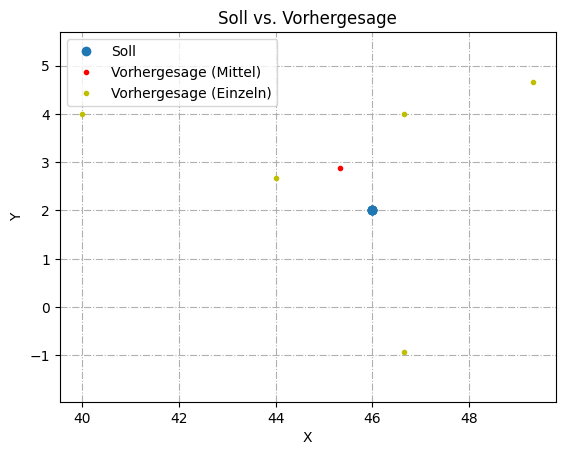

In [18]:
x = 46
y = 2

indices =  (y_validation['position_x'] == x) & (y_validation['position_y'] == y)

fig, ax = plt.subplots()

ax.grid(True, linestyle='-.')
ax.axis('equal')
ax.plot(y_validation.loc[indices, 'position_x'],y_validation.loc[indices, 'position_y'], 'o', label="Soll")
ax.plot(y_validation_pred[indices, 0].mean(),y_validation_pred[indices, 1].mean(), 'r.', label="Vorhergesage (Mittel)")
ax.plot(y_validation_pred[indices, 0],y_validation_pred[indices, 1], 'y.', label="Vorhergesage (Einzeln)")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Soll vs. Vorhergesage")
ax.legend()
plt.show()